# MNIST: van data begrijpen naar je eerste neurale netwerk

In deze opdracht doorloop je een kleine maar complete machine-learningworkflow met MNIST:

**data begrijpen → EDA → train/test split → preprocessing → baseline → neural network → evaluatie**

Je hoeft nog niet alle Python-syntax uit je hoofd te kennen. Bij nieuwe pandas- en Keras-stappen krijg je daarom steeds:

- de functie of methode die je nodig hebt;
- een korte uitleg van wat die functie doet;
- een code-skelet of gerichte hint.

Daarna schrijf je zelf de relevante regel code.

De uitgebreidere visualisatiecode met matplotlib en seaborn staat meestal al voor je klaar. Het doel is dat je zowel leert programmeren als begrijpt waarom iedere stap nodig is.

## Leerdoelen

Na deze opdracht kun je:

- een pandas `DataFrame` inspecteren met veelgebruikte functies;
- labels tellen, data selecteren, groeperen en eenvoudige nieuwe variabelen maken;
- relevante EDA-resultaten interpreteren;
- uitleggen waarom train-, validation- en testdata verschillende functies hebben;
- preprocessingkeuzes voor MNIST onderbouwen;
- een eenvoudige baseline bepalen;
- met Keras zelf een eenvoudig Dense neural network opbouwen, compileren en trainen;
- learning curves, test accuracy en een confusion matrix interpreteren;
- uitleggen waarom goede prestaties op MNIST begrensd bewijs zijn voor een echte toepassing.

# 1. Setup

Voer deze cellen uit. Dit is alleen de technische voorbereiding; deze code hoef je niet zelf te schrijven.

In [1]:
%pip install -q pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


C:\Users\Thoembs\Projecten\Opdracht\.venv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 20)
np.random.seed(42)

print("Libraries geladen.")

Libraries geladen.


# 2. MNIST laden

MNIST bestaat uit afbeeldingen van handgeschreven cijfers van 0 t/m 9.

Iedere afbeelding is **28 × 28 pixels = 784 pixelwaarden**. In deze dataset is iedere afbeelding platgeslagen tot één rij.

- 1 rij = 1 afbeelding
- 784 pixelkolommen = features
- `label` = het juiste cijfer

De dataset wordt hieronder al volledig voor je geladen. Je hoeft het ophalen en omzetten van MNIST dus niet zelf te programmeren.

In [3]:
mnist = fetch_openml("mnist_784", version=1, as_frame=True)

X = mnist.data.astype("uint8")
y = mnist.target.astype("int8")

pixel_cols = X.columns.tolist()

df = X.copy()
df["label"] = y.to_numpy()

print("Dataset geladen.")

Dataset geladen.


## 2.1 Eerste pandas-stappen

Een pandas `DataFrame` is een tabel. Drie functies die je vaak gebruikt:

```python
df.shape
df.head()
df["kolomnaam"].value_counts()
```

Schrijf hieronder zelf drie regels waarmee je:

1. de vorm van `df` bekijkt;
2. de eerste vijf rijen toont;
3. telt hoe vaak ieder label voorkomt.

In [4]:
print(df.shape)
display(df.head())
display(df["label"].value_counts().sort_index())

(70000, 785)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


label
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

**Korte vraag:** waarom heeft `df` 785 kolommen terwijl een MNIST-afbeelding maar 784 pixels heeft?

>

**Uitwerking:**

Er zijn 784 pixelkolommen en één extra kolom voor het label.


# 3. Sanity check

Voordat we grafieken maken, controleren we of de data technisch logisch is.

Gebruik hiervoor de volgende pandas-methodes:

```python
.unique()                  # unieke waarden
.isna().sum().sum()        # totaal aantal ontbrekende waarden
.min()                     # minimum
.max()                     # maximum
```

Bij de pixelwaarden moet je eerst alleen de pixelkolommen selecteren met `df[pixel_cols]`.

Vul de vijf variabelen hieronder zelf in.

In [5]:
dataset_shape = df.shape
labels = df["label"].unique()
missing_values = df.isna().sum().sum()
min_pixel = df[pixel_cols].min().min()
max_pixel = df[pixel_cols].max().max()

print("Vorm:", dataset_shape)
print("Labels:", sorted(labels))
print("Ontbrekende waarden:", missing_values)
print("Pixelrange:", min_pixel, "t/m", max_pixel)

Vorm: (70000, 785)
Labels: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9)]
Ontbrekende waarden: 0
Pixelrange: 0 t/m 255


## 3.1 Zelf een steekproef nemen

Met:

```python
DataFrame.sample(n=..., random_state=...)
```

kun je willekeurige rijen bekijken.

Schrijf één regel waarmee je **vijf** willekeurige rijen uit `df` toont. Gebruik `random_state=42`.

In [6]:
display(df.sample(n=5, random_state=42))

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
46730,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
48393,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
41416,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
34506,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
43725,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7


# 4. Train- en testdata maken

De testset simulereert data die we tijdens modelontwikkeling nog niet kennen. Daarom zetten we deze vroeg apart.

Gebruik `train_test_split()` met:

- `test_size=0.20`
- `random_state=42`
- `stratify=y_all`

De features en target zijn al voor je geselecteerd. Maak daarna zelf de split af.

In [7]:
X_all = df[pixel_cols]
y_all = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (56000, 784) (56000,)
Test: (14000, 784) (14000,)


## 4.1 Controleer de klasseverdeling

Met:

```python
Series.value_counts(normalize=True)
```

bereken je verhoudingen in plaats van aantallen. Met `.sort_index()` zet je de labels daarna weer netjes van 0 t/m 9.

Schrijf zelf de twee regels voor train en test. De tabel eronder staat al klaar.

In [8]:
train_percentage = y_train.value_counts(normalize=True).sort_index()
test_percentage = y_test.value_counts(normalize=True).sort_index()

split_check = pd.DataFrame({
    "train_%": (train_percentage * 100).round(2),
    "test_%": (test_percentage * 100).round(2)
})
display(split_check)

,train_%,test_%
label,,
0,9.86,9.86
1,11.25,11.25
2,9.99,9.99
3,10.20,10.20
4,9.75,9.75
5,9.02,9.02
6,9.82,9.82
7,10.42,10.42
8,9.75,9.75


**Korte vraag:** wat laat deze tabel zien over het effect van `stratify`?

>

**Uitwerking:**

De percentages in train en test zijn vrijwel gelijk. Dat is het doel van stratified sampling.


# 5. EDA op de trainingsdata

Vanaf nu doen we de inhoudelijke EDA op de trainingsdata.

Maak eerst zelf `train_df`:

1. maak een kopie van `X_train` met `.copy()`;
2. voeg daarna `y_train` toe als kolom `"label"`.

Hint voor stap 2:

```python
train_df["label"] = y_train.to_numpy()
```

In [9]:
train_df = X_train.copy()
train_df["label"] = y_train
display(train_df.head())

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
24367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33964,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
58668,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63075,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
49210,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 5.1 Hoe zijn de cijfers verdeeld?

Gebruik op de kolom `label`:

```python
.value_counts()
.sort_index()
```

om het aantal voorbeelden per cijfer te tellen.

Schrijf alleen de pandas-regel. De seaborn-visualisatie staat al voor je klaar.

label
0    5522
1    6302
2    5592
3    5713
4    5459
5    5050
6    5501
7    5834
8    5460
9    5567
Name: count, dtype: int64

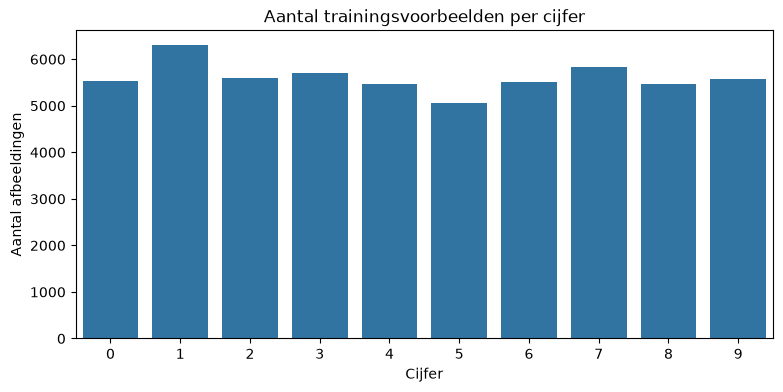

In [10]:
label_counts = train_df["label"].value_counts().sort_index()

display(label_counts)

plt.figure(figsize=(9, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Aantal trainingsvoorbeelden per cijfer")
plt.xlabel("Cijfer")
plt.ylabel("Aantal afbeeldingen")
plt.show()

Gebruik vervolgens:

```python
.idxmax()
.idxmin()
```

om te vinden welk label het vaakst en minst vaak voorkomt.

In [11]:
most_common_label = label_counts.idxmax()
least_common_label = label_counts.idxmin()

print("Meest voorkomende label:", most_common_label)
print("Minst voorkomende label:", least_common_label)

Meest voorkomende label: 1
Minst voorkomende label: 5


**Interpretatie:** is de class imbalance hier groot genoeg om direct oversampling nodig te maken?

>

**Uitwerking:**

De klasseverdeling is redelijk evenwichtig. Direct oversamplen is daarom niet nodig.


## 5.2 Bekijk echte afbeeldingen

Bij beelddata hoort ook visuele inspectie.

Kies zelf eerst tien willekeurige rijen met `.sample()`. De matplotlib-code zet de 784 pixels daarna terug naar 28×28.

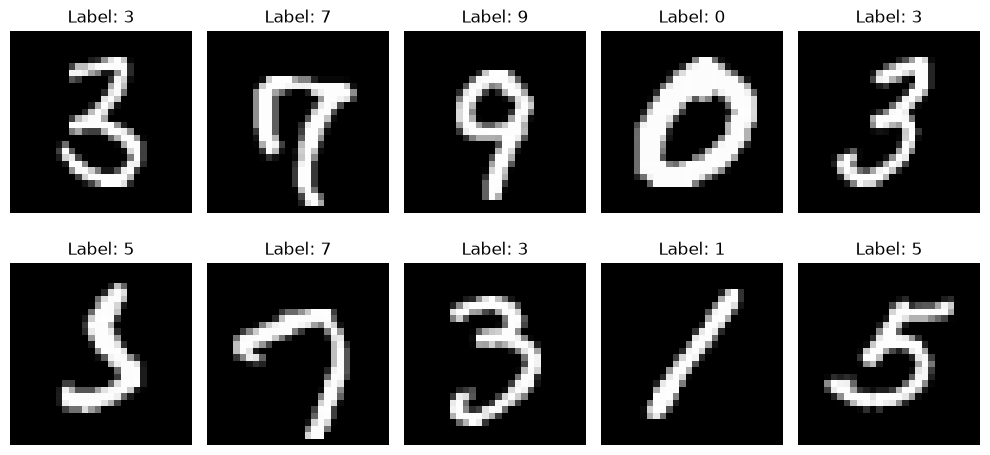

In [12]:
# Schrijf zelf deze pandas-regel.
sample = train_df.sample(n=10, random_state=42)   # neem 10 rijen uit train_df, random_state=42

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    image = row[pixel_cols].to_numpy(dtype=np.uint8).reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {int(row['label'])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Korte observatie:** noem één eigenschap die je bij meerdere afbeeldingen terugziet en die relevant kan zijn voor een model.

>

**Uitwerking:**

De cijfers verschillen in handschrift, dikte en positie. Die variatie kan de herkenning moeilijker maken.


# 6. Van pixels naar eenvoudige EDA-features

784 losse pixels zijn lastig te interpreteren. Daarom maken we drie samenvattende variabelen per afbeelding.

Gebruik:

```python
X_train.mean(axis=1)
(condition).sum(axis=1)
```

Maak zelf:

- `mean_intensity`: gemiddelde pixelwaarde;
- `active_pixels`: aantal pixels groter dan 0;
- `bright_pixels`: aantal pixels groter dan of gelijk aan 200.

De eerste twee regels om `train_eda` te maken staan klaar.

In [13]:
train_eda = pd.DataFrame(index=X_train.index)
train_eda["label"] = y_train

# Schrijf de drie pandas-regels zelf.
train_eda["mean_intensity"] = X_train.mean(axis=1)
train_eda["active_pixels"] = (X_train > 0).sum(axis=1)
train_eda["bright_pixels"] = (X_train > 128).sum(axis=1)

display(train_eda.head())

,label,mean_intensity,active_pixels,bright_pixels
24367,0,48.524235,217,152
33964,7,34.233418,137,105
58668,0,34.937500,158,110
63075,9,31.252551,152,98
49210,1,16.806122,74,48


## 6.1 Actieve pixels per cijfer

De seaborn-code staat al klaar. Je hoeft de syntax van `sns.boxplot()` nog niet uit je hoofd te kennen.

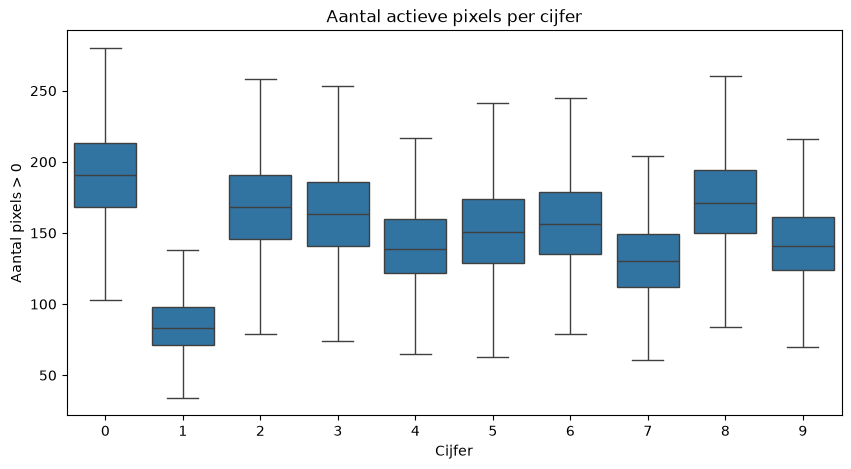

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=train_eda,
    x="label",
    y="active_pixels",
    showfliers=False
)
plt.title("Aantal actieve pixels per cijfer")
plt.xlabel("Cijfer")
plt.ylabel("Aantal pixels > 0")
plt.show()

## 6.2 Eenvoudig groeperen met pandas

Met:

```python
DataFrame.groupby("label")["kolom"].mean()
```

kun je per label een gemiddelde berekenen.

Bereken zelf het gemiddelde aantal `active_pixels` per label.

In [15]:
mean_active_by_label = train_eda.groupby("label")["active_pixels"].mean()

display(mean_active_by_label.round(1))

print("Minste gemiddeld actieve pixels:", mean_active_by_label.idxmin())
print("Meeste gemiddeld actieve pixels:", mean_active_by_label.idxmax())

label
0    191.8
1     86.0
2    169.0
3    163.9
4    141.7
5    152.5
6    157.9
7    131.6
8    173.5
9    143.5
Name: active_pixels, dtype: float64

Minste gemiddeld actieve pixels: 1
Meeste gemiddeld actieve pixels: 0


## 6.3 Het gemiddelde cijfer per klasse

Maak eerst met pandas één tabel waarin voor ieder label de gemiddelde waarde van alle pixelkolommen staat.

Gebruik:

```python
train_df.groupby("label")[pixel_cols].mean()
```

Schrijf die regel zelf. De visualisatie staat daarna klaar.

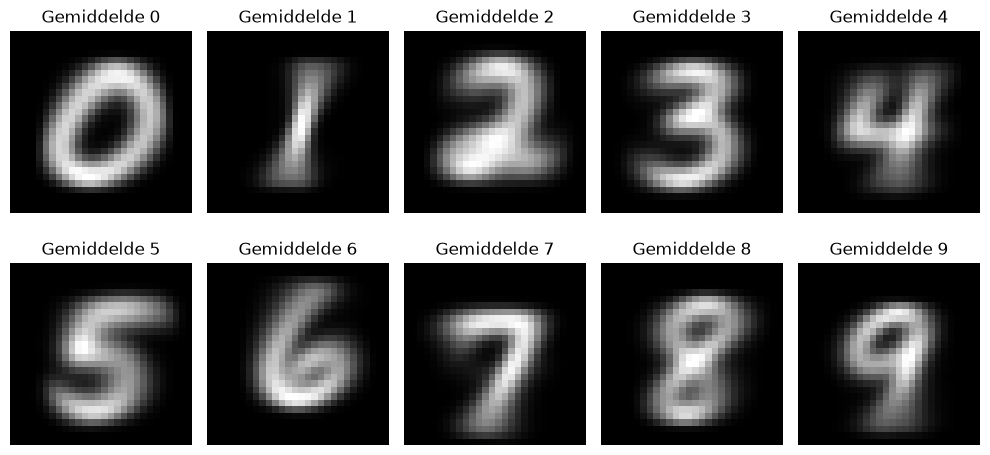

In [16]:
mean_digits = train_df.groupby("label")[pixel_cols].mean()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for label, ax in zip(range(10), axes.flat):
    avg_image = mean_digits.loc[label].to_numpy().reshape(28, 28)
    ax.imshow(avg_image, cmap="gray")
    ax.set_title(f"Gemiddelde {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 7. Datakwaliteit controleren

Gebruik pandas om vier controles zelf uit te voeren.

Je hebt hiervoor nodig:

```python
.isna().sum().sum()
.min().min()
.max().max()
.duplicated().sum()
```

Vul de variabelen in.

In [17]:
missing_pixels = X_train.isna().sum().sum()
min_pixel = X_train.min().min()
max_pixel = X_train.max().max()
duplicate_images = X_train.duplicated().sum()

print("Ontbrekende pixelwaarden:", missing_pixels)
print("Pixelrange:", min_pixel, "t/m", max_pixel)
print("Exacte dubbele afbeeldingen:", duplicate_images)

Ontbrekende pixelwaarden: 0
Pixelrange: 0 t/m 255
Exacte dubbele afbeeldingen: 0


# 8. Preprocessing kiezen

Gebruik je EDA-resultaten en vul alleen de kolom **Nodig?** in.

| Mogelijke stap | Nodig? | Aanwijzing |
|---|---|---|
| Missing values imputeren |  | Kijk naar je missing-value check |
| Pixels normaliseren naar 0–1 |  | Pixels liggen nu tussen 0 en 255 |
| Oversampling |  | Kijk naar de class distribution |
| One-hot encoding van pixels |  | Pixels zijn numerieke intensiteiten |
| Data augmentation |  | Kan nuttig zijn, maar is niet noodzakelijk voor deze eerste benchmark |

**Uitwerking:**

| Mogelijke stap | Nodig? | Reden |
|---|---|---|
| Missing values imputeren | Nee | 0 ontbrekende waarden |
| Normaliseren | Ja | Pixelwaarden omzetten naar 0–1 |
| Oversampling | Nee | Klassen zijn redelijk evenwichtig |
| One-hot encoding pixels | Nee | Pixels zijn numeriek |
| Data augmentation | Optioneel | Kan generalisatie verbeteren |


## 8.1 Normaliseren

Zet nu zelf de train- en testfeatures om naar `float32` en deel alle waarden door `255.0`.

Gebruik:

```python
DataFrame.astype("float32")
```

Maak twee nieuwe variabelen: `X_train_scaled` en `X_test_scaled`.

In [18]:
X_train_scaled = X_train.astype("float32") / 255.0
X_test_scaled = X_test.astype("float32") / 255.0

print("Train min:", X_train_scaled.min().min())
print("Train max:", X_train_scaled.max().max())
print("Datatype:", X_train_scaled.dtypes.iloc[0])

Train min: 0.0
Train max: 1.0
Datatype: float32


**Korte vraag:** waarom mag dezelfde vaste deling door 255 op train én test worden toegepast, terwijl je bijvoorbeeld een `StandardScaler` niet op de volledige dataset zou fitten?

>

**Uitwerking:**

Delen door 255 gebruikt een vooraf bekende vaste schaal. Een StandardScaler moet parameters uitsluitend op de trainingsdata leren.


# 9. EDA-conclusie vóór modelleren

Vul de drie zinnen aan met je eigen resultaten.

- De dataset bevat ...
- Daarom voeren we als preprocessing ...
- Voor een echte toepassing buiten MNIST is een belangrijk risico ...

**Uitwerking:**

De dataset heeft 70000 afbeeldingen en
785 kolommen, inclusief het label.
Er zijn 0 ontbrekende waarden en
0 exacte duplicaten in de trainingsdata.
We normaliseren de pixels naar 0–1.
Een belangrijk risico buiten MNIST is dat echte handgeschreven
cijfers anders kunnen zijn dan de trainingsvoorbeelden.


# 10. Van EDA naar je eerste neural network

We vervolgen dezelfde workflow:

**validation → baseline → model → training → generalization → test → foutenanalyse**

De input bestaat uit 784 genormaliseerde pixelwaarden. Het target is één cijfer van 0 t/m 9.

## 10.1 Maak een validation set

We gebruiken opnieuw `train_test_split()`, maar nu alleen binnen onze trainingsdata.

Gebruik:

- `test_size=0.20`
- `random_state=42`
- `stratify=y_train`

Schrijf de split zelf.

In [19]:
X_model_train, X_val, y_model_train, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model train:", X_model_train.shape)
print("Validation: ", X_val.shape)

Model train: (44800, 784)
Validation:  (11200, 784)


Keras werkt gemakkelijk met NumPy-arrays. Gebruik op iedere DataFrame of Series:

```python
.to_numpy()
```

Zet zelf train, validation en test om.

In [20]:
train_images = X_model_train.to_numpy()
val_images = X_val.to_numpy()
test_images = X_test_scaled.to_numpy()

train_labels = y_model_train.to_numpy()
val_labels = y_val.to_numpy()
test_labels = y_test.to_numpy()

print(train_images.shape, val_images.shape, test_images.shape)

(44800, 784) (11200, 784) (14000, 784)


# 11. Eerst een baseline

De random baseline is bij tien ongeveer even waarschijnlijke klassen ongeveer 10%.

Bereken zelf de majority baseline met:

```python
y_model_train.value_counts(normalize=True).max()
```

In [21]:
random_baseline = 1 / 10
majority_baseline = y_model_train.value_counts(normalize=True).max()

print(f"Random baseline: {random_baseline:.2%}")
print(f"Majority baseline: {majority_baseline:.2%}")

Random baseline: 10.00%
Majority baseline: 11.25%


# 12. Bouw het neural network

Gebruik Keras om dit netwerk zelf op te bouwen:

```text
784 inputs
    ↓
Dense(512) + ReLU
    ↓
Dense(10) + Softmax
```

De structuur van `Sequential` staat hieronder. Vul de getallen en activatiefuncties zelf in.

Gebruik:

```python
keras.Input(shape=(...,))
layers.Dense(..., activation="...")
```

In [22]:
import keras
from keras import layers

keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

**Korte vraag:** waarom heeft de laatste laag precies 10 units?

>

**Uitwerking:**

Er zijn tien output-units omdat MNIST tien klassen bevat: 0 t/m 9.


# 13. Compile het model

Gebruik:

- optimizer: `"adam"`
- loss: `"sparse_categorical_crossentropy"`
- metric: `"accuracy"`

Schrijf zelf de `model.compile(...)`-aanroep.

In [23]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 14. Train het model

Gebruik `model.fit()` met:

- `train_images`
- `train_labels`
- `epochs=10`
- `batch_size=128`
- `validation_data=(val_images, val_labels)`

Bewaar het resultaat in een variabele `history`.

In [24]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(val_images, val_labels)
)

Epoch 1/10


  1/350 ━━━━━━━━━━━━━━━━━━━━ 9:49 2s/step - accuracy: 0.0625 - loss: 2.3766

  7/350 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4888 - loss: 1.7997 

 13/350 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6244 - loss: 1.4022

 20/350 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6984 - loss: 1.1422

...

324/350 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0082

331/350 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9991 - loss: 0.0083

338/350 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9991 - loss: 0.0082

345/350 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0082

350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9991 - loss: 0.0082 - val_accuracy: 0.9773 - val_loss: 0.0791


# 15. Learning curves

Keras bewaart de scores in `history.history`.

Maak daar eerst zelf een pandas DataFrame van met:

```python
pd.DataFrame(...)
```

De seaborn-code voor de curves staat daarna klaar.

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
1,0.9145,0.3034,0.9516,0.1675
2,0.9635,0.1277,0.9667,0.1175
3,0.9766,0.0835,0.9714,0.0962
4,0.9839,0.0589,0.9726,0.0869
5,0.9895,0.0416,0.9727,0.0829
6,0.9932,0.0296,0.9744,0.0796
7,0.9959,0.0209,0.9764,0.0781
8,0.9976,0.0147,0.9761,0.0792
9,0.9985,0.0107,0.9779,0.0780


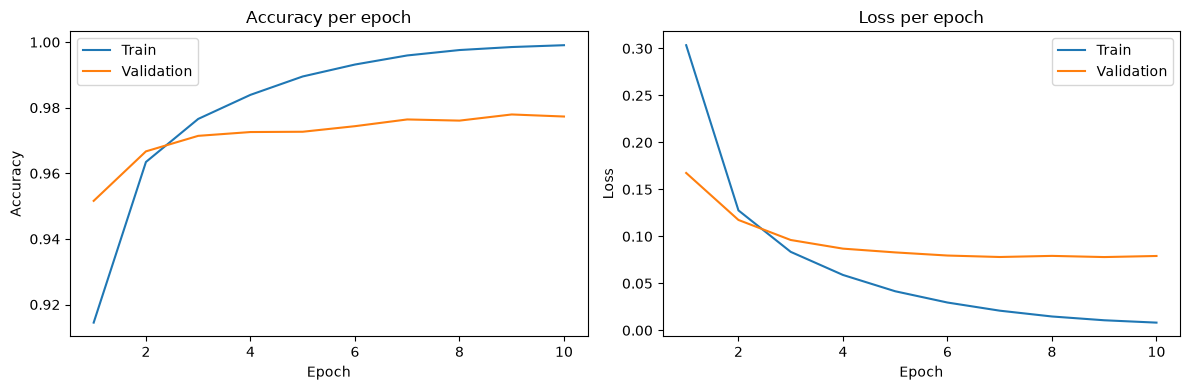

In [25]:
history_df = pd.DataFrame(history.history)

history_df.index = history_df.index + 1
history_df.index.name = "epoch"

display(history_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=history_df.index, y=history_df["accuracy"], label="Train", ax=axes[0])
sns.lineplot(x=history_df.index, y=history_df["val_accuracy"], label="Validation", ax=axes[0])
axes[0].set_title("Accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

sns.lineplot(x=history_df.index, y=history_df["loss"], label="Train", ax=axes[1])
sns.lineplot(x=history_df.index, y=history_df["val_loss"], label="Validation", ax=axes[1])
axes[1].set_title("Loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

**Interpretatie:** zie je een moment waarop training nog verbetert, terwijl validation nauwelijks meer verbetert of slechter wordt?

>

**Uitwerking:**

De uiteindelijke trainingsaccuracy is
99.91% en de validation accuracy
97.73%.
Bekijk de learning curves om te beoordelen of er overfitting optreedt.


# 16. Nu pas: de testset

Gebruik:

```python
model.evaluate(...)
```

om de uiteindelijke test loss en test accuracy te berekenen.

De functie geeft twee waarden terug. Sla die op als `test_loss` en `test_accuracy`.

In [26]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Majority baseline: {majority_baseline:.2%}")

  1/438 ━━━━━━━━━━━━━━━━━━━━ 58s 134ms/step - accuracy: 0.9688 - loss: 0.0333

 10/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9688 - loss: 0.0979   

 21/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9732 - loss: 0.0914

 31/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9758 - loss: 0.0925

 41/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9771 - loss: 0.0895

...

412/438 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9800 - loss: 0.0770

423/438 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9803 - loss: 0.0762

434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9801 - loss: 0.0768

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9801 - loss: 0.0764


Test loss:     0.0764
Test accuracy: 98.01%
Majority baseline: 11.25%


# 17. Voorspellingen maken

Gebruik:

```python
model.predict(test_images)
```

om voor alle testafbeeldingen voorspellingen te maken.

Gebruik daarna `.argmax(axis=1)` om van de tien Softmax-scores per afbeelding één voorspeld label te maken.

In [27]:
predictions = model.predict(test_images)
y_pred = predictions.argmax(axis=1)

print("Vorm van predictions:", predictions.shape)
print("Eerste 10 voorspelde labels:", y_pred[:10])

  1/438 ━━━━━━━━━━━━━━━━━━━━ 1:14 171ms/step

 19/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    

 38/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

 58/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

 76/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

414/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

428/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


Vorm van predictions: (14000, 10)
Eerste 10 voorspelde labels: [7 3 1 1 2 5 9 8 8 1]


## 17.1 Bekijk één voorspelling

De visualisatiecode staat klaar. Verander `example_index` gerust naar een ander getal.

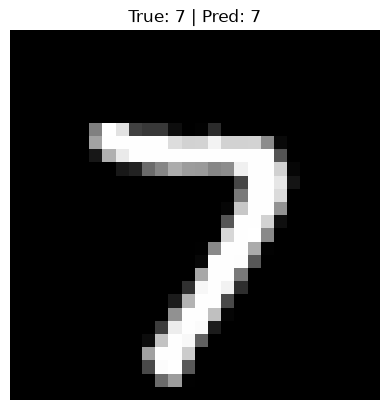

Softmax-scores: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Hoogste score: 1.0


In [28]:
example_index = 0

scores = predictions[example_index]
predicted_class = y_pred[example_index]
true_class = test_labels[example_index]

plt.imshow(test_images[example_index].reshape(28, 28), cmap="gray")
plt.title(f"True: {true_class} | Pred: {predicted_class}")
plt.axis("off")
plt.show()

print("Softmax-scores:", np.round(scores, 3))
print("Hoogste score:", round(float(scores.max()), 3))

# 18. Confusion matrix

De voorspellingen `y_pred` heb je zelf gemaakt. Nu gebruiken we die om een confusion matrix te berekenen en met seaborn te visualiseren.

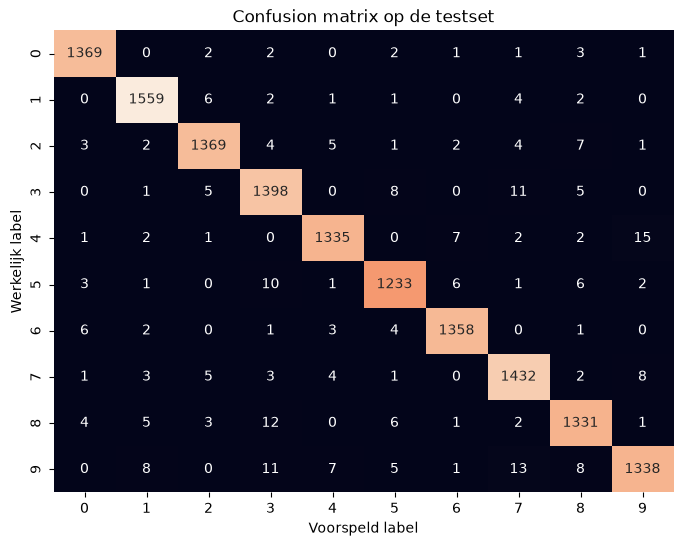

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Confusion matrix op de testset")
plt.xlabel("Voorspeld label")
plt.ylabel("Werkelijk label")
plt.show()

**Korte observatie:** noem één combinatie van cijfers die het model relatief vaak met elkaar verwart.

>

**Uitwerking:**

Het model verwart onder andere 4 met 9.
Dit gebeurde 15 keer in de testset.


# 19. Bekijk echte fouten

De code hieronder selecteert tien fout geclassificeerde voorbeelden. Je hoeft deze matplotlib-code niet zelf te schrijven.

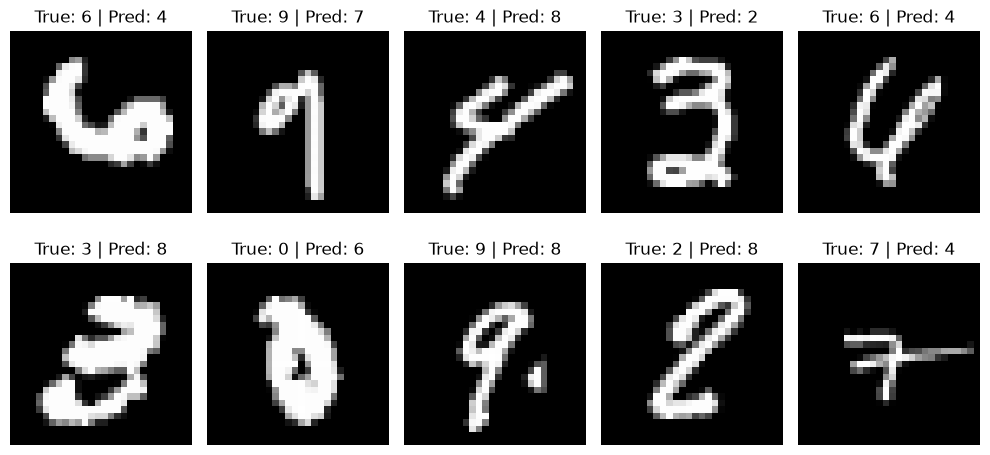

In [30]:
wrong_indices = np.where(y_pred != test_labels)[0]
chosen = wrong_indices[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, idx in zip(axes.flat, chosen):
    ax.imshow(test_images[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {int(test_labels[idx])} | Pred: {int(y_pred[idx])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 20. Eindconclusie

Schrijf ongeveer 5–6 zinnen waarin je de hele workflow samenvat. Verwerk daarin:

**wat je EDA liet zien → welke preprocessing je koos → waarom train/validation/test gescheiden zijn → hoe het neural network presteerde → welke beperking MNIST heeft voor een echte toepassing.**

>

**Uitwerking:**

De EDA laat zien dat MNIST 70000 afbeeldingen
bevat met tien cijferklassen. De pixelwaarden zijn genormaliseerd
naar 0–1. We gebruikten afzonderlijke train-, validation- en
testsets om datalekken en te optimistische evaluatie te voorkomen.
Het neurale netwerk behaalde 98.01% accuracy
op de testset, tegenover 11.25% voor de
majority baseline. Een voorbeeld van een verwarring is
4 voorspellen bij een echte 9, of omgekeerd.
MNIST is relatief schoon en representatief voor echte
handschrifttoepassingen is daarmee niet gegarandeerd.


In [31]:
import json
from sklearn.metrics import confusion_matrix

summary = {
    "shape": list(df.shape),
    "missing": int(missing_values),
    "min_pixel": int(min_pixel),
    "max_pixel": int(max_pixel),
    "duplicates": int(duplicate_images),
    "most_common": int(most_common_label),
    "least_common": int(least_common_label),
    "min_active": int(mean_active_by_label.idxmin()),
    "max_active": int(mean_active_by_label.idxmax()),
    "train_accuracy": float(history.history["accuracy"][-1]),
    "val_accuracy": float(history.history["val_accuracy"][-1]),
    "val_history": [float(v) for v in history.history["val_accuracy"]],
    "test_accuracy": float(test_accuracy),
    "majority_baseline": float(majority_baseline),
    "confusions": [
        [int(i), int(j), int(cm[i,j])]
        for i in range(10) for j in range(10) if i != j
    ]
}
print("RESULT_JSON:" + json.dumps(summary))

RESULT_JSON:{"shape": [70000, 785], "missing": 0, "min_pixel": 0, "max_pixel": 255, "duplicates": 0, "most_common": 1, "least_common": 5, "min_active": 1, "max_active": 0, "train_accuracy": 0.9990624785423279, "val_accuracy": 0.977321445941925, "val_history": [0.9516071677207947, 0.9666964411735535, 0.9714285731315613, 0.9725893139839172, 0.972678542137146, 0.9743750095367432, 0.9764285683631897, 0.9760714173316956, 0.977946400642395, 0.977321445941925], "test_accuracy": 0.9801428318023682, "majority_baseline": 0.11254464285714286, "confusions": [[0, 1, 0], [0, 2, 2], [0, 3, 2], [0, 4, 0], [0, 5, 2], [0, 6, 1], [0, 7, 1], [0, 8, 3], [0, 9, 1], [1, 0, 0], [1, 2, 6], [1, 3, 2], [1, 4, 1], [1, 5, 1], [1, 6, 0], [1, 7, 4], [1, 8, 2], [1, 9, 0], [2, 0, 3], [2, 1, 2], [2, 3, 4], [2, 4, 5], [2, 5, 1], [2, 6, 2], [2, 7, 4], [2, 8, 7], [2, 9, 1], [3, 0, 0], [3, 1, 1], [3, 2, 5], [3, 4, 0], [3, 5, 8], [3, 6, 0], [3, 7, 11], [3, 8, 5], [3, 9, 0], [4, 0, 1], [4, 1, 2], [4, 2, 1], [4, 3, 0], [4, 5,